# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [27]:
STUDENT_NAME = "Phu Thanh"  # TODO: Họ và tên
STUDENT_ID = "24521364"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Phu Thanh (24521364)


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: D:\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


In [3]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [4]:
# TODO N1
# Tính shifted_logits bằng cách trừ max value theo row
shifted_logits = logits - logits.max(axis=1, keepdims=True)

# Tính exponential
exp_logits = np.exp(shifted_logits)

# Tính softmax (normalize theo row)
class_probabilities = exp_logits / exp_logits.sum(axis=1, keepdims=True)

# Lấy class có xác suất lớn nhất (argmax)
predicted_classes = np.argmax(class_probabilities, axis=1)

# Lấy xác suất lớn nhất
confidence_scores = np.max(class_probabilities, axis=1)

In [5]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


In [6]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [7]:
# TODO N2
# Tính mean và std chỉ từ X_train
train_feature_mean = X_train.mean(axis=0)
train_feature_std = X_train.std(axis=0)

# Chuẩn hóa X_train
X_train_scaled = (X_train - train_feature_mean) / train_feature_std

# Chuẩn hóa X_val dùng mean/std từ train
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [8]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


In [9]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [10]:
# TODO N3
# Mask dự đoán đúng
correct_mask = predicted_classes == true_labels

# Mask confidence cao
high_confidence_mask = confidence_scores >= confidence_threshold

# Mask cần review (dự đoán sai HOẶC confidence thấp)
review_mask = ~correct_mask | ~high_confidence_mask

# Indices cần review
review_indices = np.where(review_mask)[0]

In [11]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [12]:
# TODO N4
# Normalize batch: chuyển từ uint8 [0, 255] sang float32 [0, 1]
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0

# Tạo batch augment bằng cách flip ngang (axis 2) và copy để có bộ nhớ độc lập
augmented_batch = np.fliplr(normalized_batch).copy()

# Đặt pixel augmented_batch[0, 0, 0, 0] = 1.0
augmented_batch[0, 0, 0, 0] = 1.0

In [13]:
# TODO D1
# Load dữ liệu sao cho dấu ? vẫn là chuỗi
raw_df = pd.read_csv(DATA_PATH)

# Lấy shape
raw_shape = raw_df.shape

# Đếm số dấu ?
raw_missing_marker_count = (raw_df == "?").sum().sum()

In [15]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [16]:
# TODO D2
# Copy raw_df để không thay đổi dữ liệu gốc
df_clean = raw_df.copy()

# Thay ? bằng np.nan
df_clean = df_clean.replace("?", np.nan)

# Chuyển các cột numeric bằng pd.to_numeric
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column], errors='coerce')

# Tạo báo cáo missing
missing_by_column = df_clean.isnull().sum()

In [17]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [18]:
# TODO D3
# Lấy 6 cột cần phân tích
analysis_df = df_clean[AUTO_FEATURES].copy()

# Drop các dòng thiếu ít nhất một cột
analysis_df = analysis_df.dropna()

# Chuyển sang float64 NumPy array
X_auto = analysis_df.values.astype(np.float64)

# Tính mean và std cho từng feature
auto_feature_mean = X_auto.mean(axis=0)
auto_feature_std = X_auto.std(axis=0)

# Chuẩn hóa dữ liệu
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

In [19]:
# TODO D4
# Tìm index của price trong AUTO_FEATURES
price_index = AUTO_FEATURES.index('price')

# Tính z-score cho price
price_values = X_auto[:, price_index]
price_mean = price_values.mean()
price_std = price_values.std()
price_z = (price_values - price_mean) / price_std

# Tìm outlier: abs(z) > 2
price_outlier_mask = np.abs(price_z) > 2

# Lấy outliers từ analysis_df
price_outliers = analysis_df[price_outlier_mask]

In [20]:
# TODO D5
# Tìm index của engine_size và price
engine_size_index = AUTO_FEATURES.index('engine_size')
price_index_d5 = AUTO_FEATURES.index('price')

# Tính Pearson correlation giữa engine_size và price
engine_size_values = X_auto[:, engine_size_index]
price_values_d5 = X_auto[:, price_index_d5]
engine_price_corr = np.corrcoef(engine_size_values, price_values_d5)[0, 1]

# Tính mean price theo body_style
price_by_body_style = df_clean.groupby('body_style')['price'].mean().sort_index()

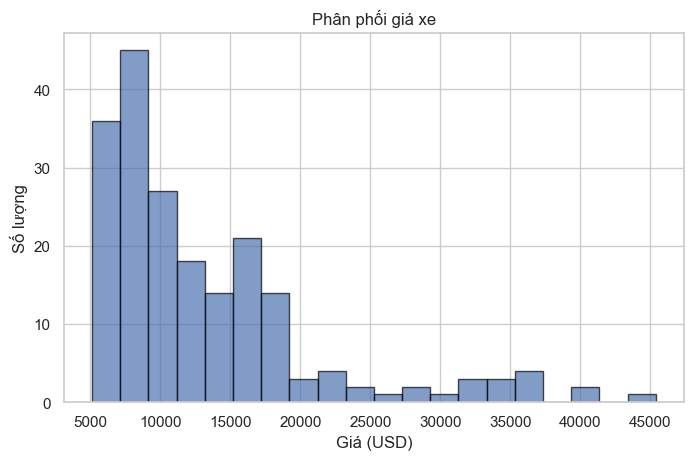

In [21]:
# TODO M2.1: histogram/KDE của price
fig, ax = plt.subplots()
df_clean['price'].dropna().hist(bins=20, ax=ax, alpha=0.7, edgecolor='black')
ax.set_title('Phân phối giá xe')
ax.set_xlabel('Giá (USD)')
ax.set_ylabel('Số lượng')
plt.show()

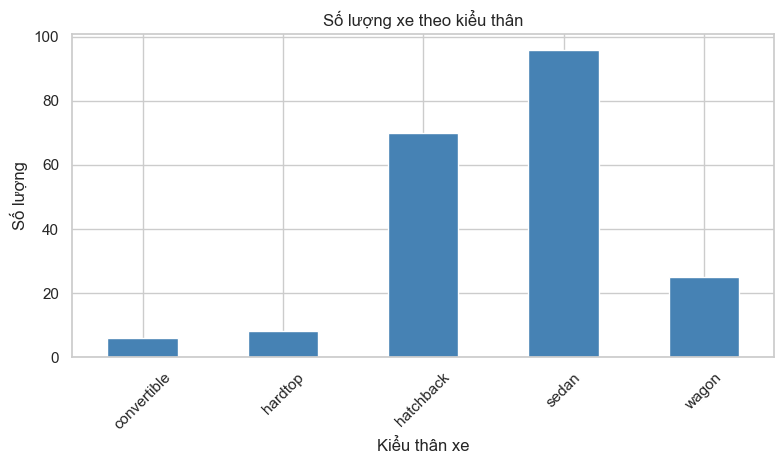

In [22]:
# TODO M2.2: countplot của body_style
fig, ax = plt.subplots()
df_clean['body_style'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Số lượng xe theo kiểu thân')
ax.set_xlabel('Kiểu thân xe')
ax.set_ylabel('Số lượng')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()

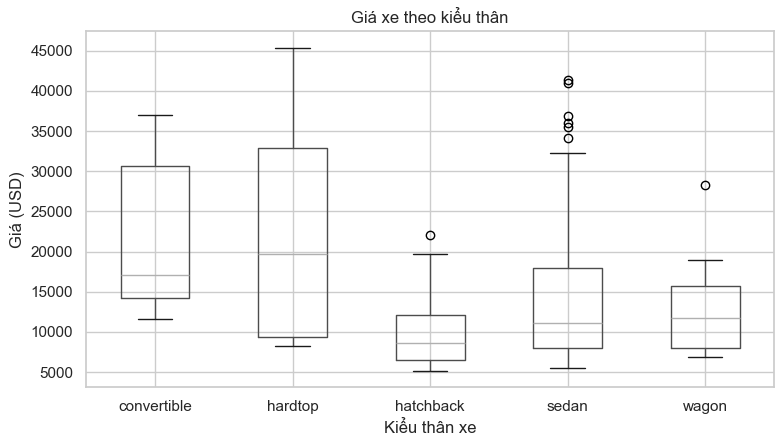

In [23]:
# TODO M2.3: boxplot price theo body_style
fig, ax = plt.subplots()
df_clean.boxplot(column='price', by='body_style', ax=ax)
ax.set_title('Giá xe theo kiểu thân')
ax.set_xlabel('Kiểu thân xe')
ax.set_ylabel('Giá (USD)')
plt.suptitle('')  # Xoá title tự động
plt.tight_layout()
plt.show()

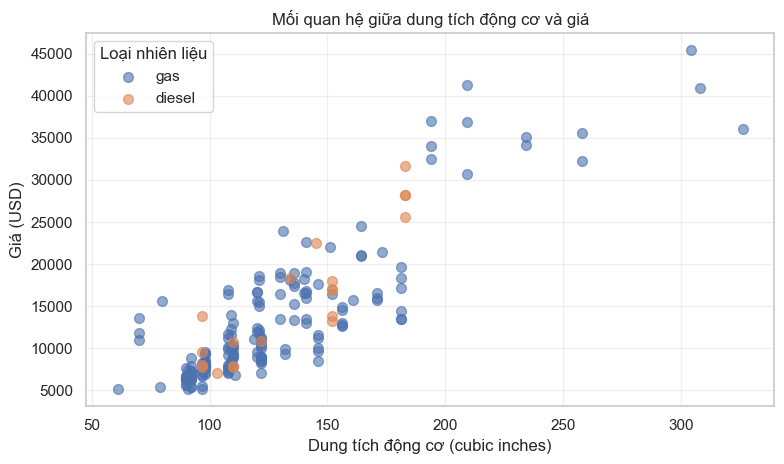

In [24]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
fig, ax = plt.subplots()
for fuel_type in df_clean['fuel_type'].unique():
    if pd.notna(fuel_type):
        mask = df_clean['fuel_type'] == fuel_type
        ax.scatter(df_clean.loc[mask, 'engine_size'], 
                  df_clean.loc[mask, 'price'],
                  label=fuel_type, alpha=0.6, s=50)
ax.set_title('Mối quan hệ giữa dung tích động cơ và giá')
ax.set_xlabel('Dung tích động cơ (cubic inches)')
ax.set_ylabel('Giá (USD)')
ax.legend(title='Loại nhiên liệu')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

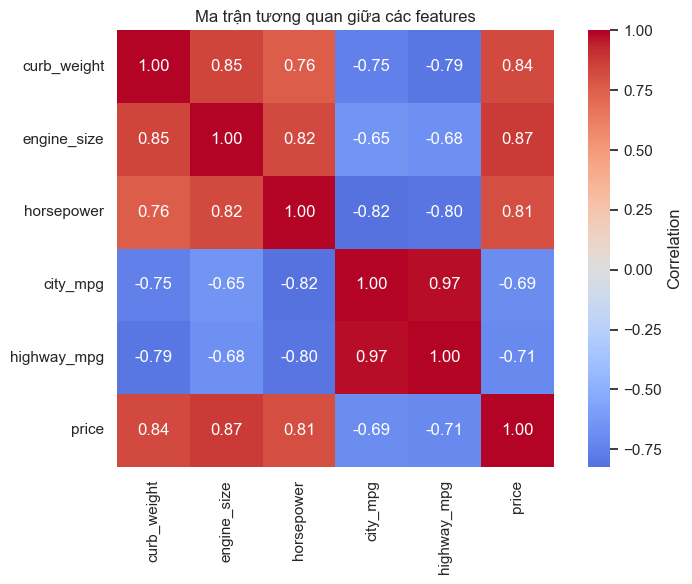

In [25]:
# TODO M2.5: correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
# Tính correlation matrix từ analysis_df
corr_matrix = analysis_df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Ma trận tương quan giữa các features')
plt.tight_layout()
plt.show()

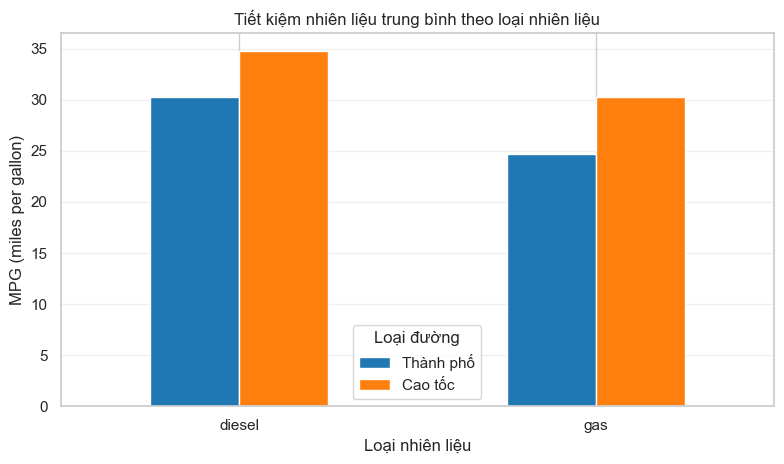

In [26]:
# TODO M2.6: biểu đồ tự chọn
# Câu hỏi: Tiết kiệm nhiên liệu (MPG) trung bình theo loại nhiên liệu ra sao?
fig, ax = plt.subplots()
mpg_by_fuel = df_clean.groupby('fuel_type')[['city_mpg', 'highway_mpg']].mean()
mpg_by_fuel.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])
ax.set_title('Tiết kiệm nhiên liệu trung bình theo loại nhiên liệu')
ax.set_xlabel('Loại nhiên liệu')
ax.set_ylabel('MPG (miles per gallon)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Loại đường', labels=['Thành phố', 'Cao tốc'])
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()